In [1]:
# Interpretable Machine Learning for 30-Day Diabetes Hospital Readmission Prediction

#Dataset:** UCI Diabetes 130-US Hospitals for Years 1999–2008
#Goal:** Predict whether a diabetic inpatient encounter results in readmission within 30 days.


#This project compares multiple machine learning models, evaluates performance using healthcare-relevant metrics, analyzes model interpretability, and checks fairness across demographic groups.

In [2]:
INSTALL_PACKAGES = True

if INSTALL_PACKAGES:
    import sys
    import subprocess

    packages = [
        "ucimlrepo",
        "scikit-learn",
        "pandas",
        "numpy",
        "matplotlib",
        "seaborn",
        "joblib"
    ]

    for pkg in packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

    optional_packages = ["xgboost", "shap"]

    for pkg in optional_packages:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        except Exception as e:
            print(f"Optional package {pkg} could not be installed: {e}")

In [3]:
import os
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports complete.")

Imports complete.


In [4]:
FAST_MODE = False
RUN_TUNING = True
RUN_OPTIONAL_XGBOOST = True
RUN_OPTIONAL_SHAP = False

print("FAST_MODE:", FAST_MODE)
print("RUN_TUNING:", RUN_TUNING)
print("RUN_OPTIONAL_XGBOOST:", RUN_OPTIONAL_XGBOOST)
print("RUN_OPTIONAL_SHAP:", RUN_OPTIONAL_SHAP)

FAST_MODE: False
RUN_TUNING: True
RUN_OPTIONAL_XGBOOST: True
RUN_OPTIONAL_SHAP: False


In [5]:
LOCAL_CSV_PATH = "diabetic_data.csv"

def load_diabetes_data():
    try:
        from ucimlrepo import fetch_ucirepo

        dataset = fetch_ucirepo(id=296)

        X = dataset.data.features.copy()
        y = dataset.data.targets.copy()

        # Add ID columns if ucimlrepo stores them separately
        if hasattr(dataset.data, "ids") and dataset.data.ids is not None:
            ids = dataset.data.ids.copy()
            X = pd.concat([ids, X], axis=1)

        if isinstance(y, pd.DataFrame):
            y_col = y.columns[0]
            y = y[y_col]

        df = X.copy()
        df["readmitted"] = y.values

        print("Loaded dataset from ucimlrepo.")
        return df

    except Exception as e:
        print("Could not load from ucimlrepo.")
        print("Error:", e)

        if Path(LOCAL_CSV_PATH).exists():
            print(f"Loading local file: {LOCAL_CSV_PATH}")
            return pd.read_csv(LOCAL_CSV_PATH)

        raise FileNotFoundError(
            "Dataset not found. Place diabetic_data.csv in the notebook folder "
            "or enable internet access for ucimlrepo."
        )

In [6]:
df_raw = load_diabetes_data()

print("Dataset shape:", df_raw.shape)
df_raw.head()

Loaded dataset from ucimlrepo.
Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
df = df_raw.copy()

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.value_counts())

Shape: (101766, 50)

Columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data types:


object    37
int64     13
Name: count, dtype: int64

In [8]:
print("Readmission outcome counts:")
display(df["readmitted"].value_counts(dropna=False))

print("Readmission outcome proportions:")
display(df["readmitted"].value_counts(normalize=True, dropna=False).round(4))

Readmission outcome counts:


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Readmission outcome proportions:


readmitted
NO     0.5391
>30    0.3493
<30    0.1116
Name: proportion, dtype: float64

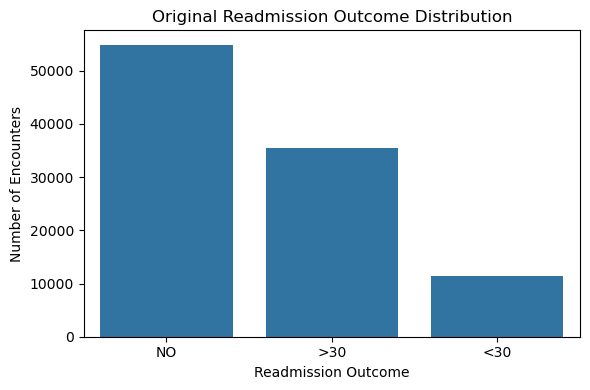

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="readmitted", order=["NO", ">30", "<30"])
plt.title("Original Readmission Outcome Distribution")
plt.xlabel("Readmission Outcome")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()

In [10]:
df_missing = df.replace("?", np.nan)

missing_rate = df_missing.isna().mean().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_rate": missing_rate,
    "missing_count": df_missing.isna().sum()
})

display(missing_summary.head(25))

,missing_rate,missing_count
A1Cresult,0.832773,84748
acarbose,0.000000,0
acetohexamide,0.000000,0
admission_source_id,0.000000,0
admission_type_id,0.000000,0
age,0.000000,0
change,0.000000,0
chlorpropamide,0.000000,0
citoglipton,0.000000,0
diabetesMed,0.000000,0


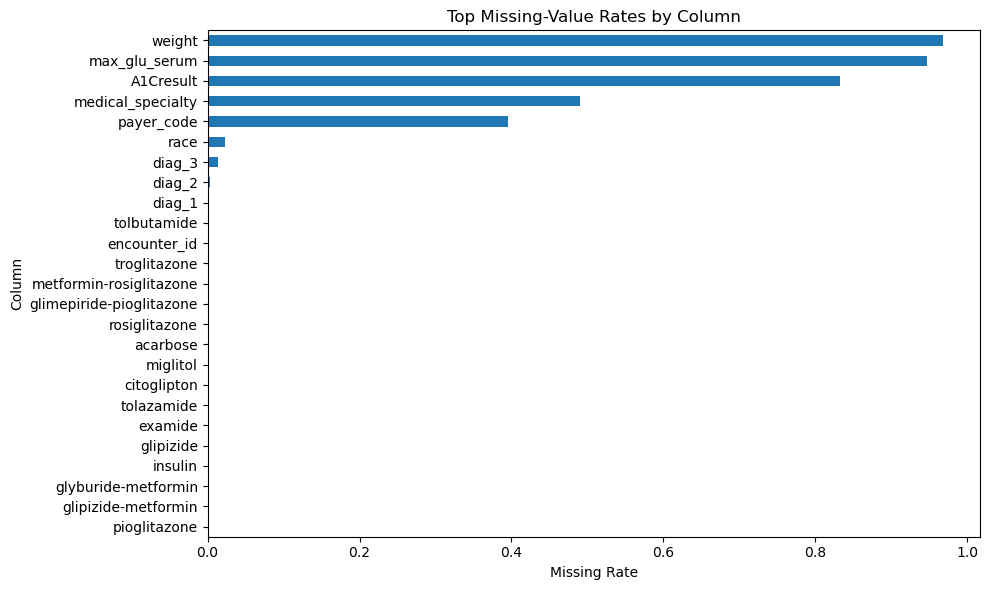

In [11]:
plt.figure(figsize=(10, 6))
missing_rate.head(25).sort_values().plot(kind="barh")
plt.title("Top Missing-Value Rates by Column")
plt.xlabel("Missing Rate")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [12]:
df = df_raw.copy().replace("?", np.nan)

df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print("Binary target counts:")
display(df["readmitted_30"].value_counts())

print("Binary target proportions:")
display(df["readmitted_30"].value_counts(normalize=True).round(4))

Binary target counts:


readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Binary target proportions:


readmitted_30
0    0.8884
1    0.1116
Name: proportion, dtype: float64

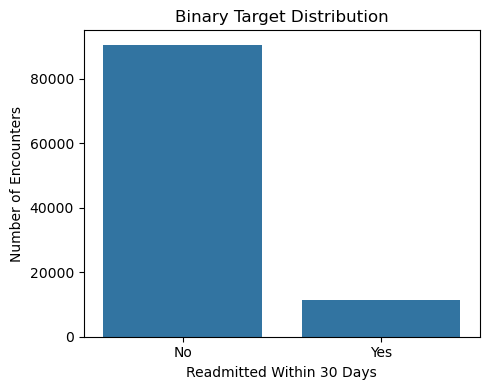

In [13]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="readmitted_30")
plt.title("Binary Target Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Number of Encounters")
plt.xticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.show()

In [14]:
REMOVE_EXPIRED_HOSPICE = True

EXPIRED_HOSPICE_DISPOSITION_IDS = {11, 13, 14, 19, 20, 21}

MEDICATION_COLUMNS = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

In [15]:
def map_icd9_to_group(code):
    if pd.isna(code):
        return "Missing"

    code = str(code).strip()

    if code == "":
        return "Missing"

    if code.startswith("V"):
        return "Supplementary_V"

    if code.startswith("E"):
        return "Supplementary_E"

    try:
        value = float(code)
    except ValueError:
        return "Other"

    if 390 <= value <= 459 or value == 785:
        return "Circulatory"
    elif 460 <= value <= 519 or value == 786:
        return "Respiratory"
    elif 520 <= value <= 579 or value == 787:
        return "Digestive"
    elif 250 <= value < 251:
        return "Diabetes"
    elif 800 <= value <= 999:
        return "Injury"
    elif 710 <= value <= 739:
        return "Musculoskeletal"
    elif 580 <= value <= 629 or value == 788:
        return "Genitourinary"
    elif 140 <= value <= 239:
        return "Neoplasms"
    elif 240 <= value <= 279:
        return "Endocrine_Except_Diabetes"
    elif 680 <= value <= 709 or value == 782:
        return "Skin"
    elif 780 <= value <= 799:
        return "Symptoms"
    else:
        return "Other"

In [16]:
AGE_MAP = {
    '[0-10)': 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}

A1C_MAP = {
    "Norm": 0,
    ">7": 1,
    ">8": 2
}

GLUCOSE_MAP = {
    "Norm": 0,
    ">200": 1,
    ">300": 2
}


def engineer_features(df_in):
    df = df_in.copy().replace("?", np.nan)

    if "gender" in df.columns:
        df["gender"] = df["gender"].replace({"Unknown/Invalid": np.nan})

    if REMOVE_EXPIRED_HOSPICE and "discharge_disposition_id" in df.columns:
        discharge_numeric = pd.to_numeric(df["discharge_disposition_id"], errors="coerce")
        before = len(df)
        df = df.loc[~discharge_numeric.isin(EXPIRED_HOSPICE_DISPOSITION_IDS)].copy()
        print(f"Removed {before - len(df)} expired/hospice discharge encounters.")

    df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

    if "age" in df.columns:
        df["age_numeric"] = df["age"].map(AGE_MAP)

    for col in ["diag_1", "diag_2", "diag_3"]:
        if col in df.columns:
            df[f"{col}_group"] = df[col].apply(map_icd9_to_group)

    if "A1Cresult" in df.columns:
        df["A1C_ordinal"] = df["A1Cresult"].map(A1C_MAP).fillna(-1)

    if "max_glu_serum" in df.columns:
        df["glucose_ordinal"] = df["max_glu_serum"].map(GLUCOSE_MAP).fillna(-1)

    med_cols_present = [col for col in MEDICATION_COLUMNS if col in df.columns]

    if med_cols_present:
        df["num_med_up"] = (df[med_cols_present] == "Up").sum(axis=1)
        df["num_med_down"] = (df[med_cols_present] == "Down").sum(axis=1)
        df["num_med_steady"] = (df[med_cols_present] == "Steady").sum(axis=1)
        df["num_med_no"] = (df[med_cols_present] == "No").sum(axis=1)

        df["total_med_dose_changes"] = df["num_med_up"] + df["num_med_down"]
        df["any_med_change_detail"] = (df["total_med_dose_changes"] > 0).astype(int)
        df["multiple_med_changes"] = (df["total_med_dose_changes"] >= 2).astype(int)

        if "insulin" in df.columns:
            df["insulin_changed"] = df["insulin"].isin(["Up", "Down"]).astype(int)

    visit_cols = ["number_outpatient", "number_emergency", "number_inpatient"]
    if all(col in df.columns for col in visit_cols):
        df["total_prior_visits"] = df[visit_cols].sum(axis=1)
        df["had_prior_outpatient"] = (df["number_outpatient"] > 0).astype(int)
        df["had_prior_emergency"] = (df["number_emergency"] > 0).astype(int)
        df["had_prior_inpatient"] = (df["number_inpatient"] > 0).astype(int)

        df["prior_visit_burden"] = (
            3 * df["number_inpatient"]
            + 2 * df["number_emergency"]
            + df["number_outpatient"]
        )

        df["log_total_prior_visits"] = np.log1p(df["total_prior_visits"])
        df["log_inpatient"] = np.log1p(df["number_inpatient"])
        df["log_emergency"] = np.log1p(df["number_emergency"])
        df["log_outpatient"] = np.log1p(df["number_outpatient"])

    if "time_in_hospital" in df.columns:
        df["long_hospital_stay"] = (df["time_in_hospital"] >= 7).astype(int)

    if "num_medications" in df.columns:
        df["high_medication_count"] = (df["num_medications"] >= 20).astype(int)
        df["log_num_medications"] = np.log1p(df["num_medications"])

    if "num_lab_procedures" in df.columns:
        df["many_lab_procedures"] = (df["num_lab_procedures"] >= 50).astype(int)
        df["log_num_lab_procedures"] = np.log1p(df["num_lab_procedures"])

    if "number_diagnoses" in df.columns:
        df["many_diagnoses"] = (df["number_diagnoses"] >= 8).astype(int)

    if all(col in df.columns for col in ["num_medications", "time_in_hospital"]):
        df["medications_per_day"] = df["num_medications"] / (df["time_in_hospital"] + 1)

    if all(col in df.columns for col in ["num_lab_procedures", "time_in_hospital"]):
        df["labs_per_day"] = df["num_lab_procedures"] / (df["time_in_hospital"] + 1)

    if all(col in df.columns for col in ["num_procedures", "time_in_hospital"]):
        df["procedures_per_day"] = df["num_procedures"] / (df["time_in_hospital"] + 1)

    if all(col in df.columns for col in ["total_prior_visits", "time_in_hospital"]):
        df["visit_intensity"] = df["total_prior_visits"] / (df["time_in_hospital"] + 1)

    return df

In [17]:
df_model = engineer_features(df_raw)

print("Modeling dataset shape:", df_model.shape)

display(df_model[[
    "readmitted",
    "readmitted_30",
    "diag_1",
    "diag_1_group",
    "diag_2",
    "diag_2_group",
    "diag_3",
    "diag_3_group"
]].head())

Removed 2423 expired/hospice discharge encounters.
Modeling dataset shape: (99343, 84)


,readmitted,readmitted_30,diag_1,diag_1_group,diag_2,diag_2_group,diag_3,diag_3_group
0,NO,0,250.83,Diabetes,NaN,Missing,NaN,Missing
1,>30,0,276,Endocrine_Except_Diabetes,250.01,Diabetes,255,Endocrine_Except_Diabetes
2,NO,0,648,Other,250,Diabetes,V27,Supplementary_V
3,NO,0,8,Other,250.43,Diabetes,403,Circulatory
4,NO,0,197,Neoplasms,157,Neoplasms,250,Diabetes


In [18]:
TARGET = "readmitted_30"
GROUP_COL = "patient_nbr"

DROP_COLUMNS = [
    "readmitted",
    "readmitted_30",
    "encounter_id",
    "patient_nbr",

    # still drop weight
    "weight"
]

y_all = df_model[TARGET].astype(int)
groups = df_model[GROUP_COL]

gss_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_val_idx, test_idx = next(
    gss_1.split(df_model, y_all, groups=groups)
)

train_val = df_model.iloc[train_val_idx].copy()
test = df_model.iloc[test_idx].copy()

In [19]:
gss_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    gss_2.split(
        train_val,
        train_val[TARGET],
        groups=train_val[GROUP_COL]
    )
)

train = train_val.iloc[train_idx].copy()
val = train_val.iloc[val_idx].copy()

In [20]:
if FAST_MODE:
    train = train.sample(
        min(len(train), 25000),
        random_state=RANDOM_STATE
    )

    val = val.sample(
        min(len(val), 8000),
        random_state=RANDOM_STATE
    )

    test = test.sample(
        min(len(test), 8000),
        random_state=RANDOM_STATE
    )

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

print("\nTrain positive rate:", train[TARGET].mean())
print("Validation positive rate:", val[TARGET].mean())
print("Test positive rate:", test[TARGET].mean())

Train shape: (59814, 84)
Validation shape: (19727, 84)
Test shape: (19802, 84)

Train positive rate: 0.11445480991072324
Validation positive rate: 0.11415826025244588
Test positive rate: 0.11190788809211191


In [21]:
X_train = train.drop(
    columns=[col for col in DROP_COLUMNS if col in train.columns]
)

y_train = train[TARGET].astype(int)

X_val = val.drop(
    columns=[col for col in DROP_COLUMNS if col in val.columns]
)

y_val = val[TARGET].astype(int)

X_test = test.drop(
    columns=[col for col in DROP_COLUMNS if col in test.columns]
)

y_test = test[TARGET].astype(int)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (59814, 79)
X_val: (19727, 79)
X_test: (19802, 79)


In [22]:
def target_summary(split_name, y):
    return pd.Series({
        "split": split_name,
        "n": len(y),
        "positive_n": int(y.sum()),
        "positive_rate": float(y.mean())
    })

split_summary = pd.DataFrame([
    target_summary("train", y_train),
    target_summary("validation", y_val),
    target_summary("test", y_test)
])

display(split_summary)

,split,n,positive_n,positive_rate
0,train,59814,6846,0.114455
1,validation,19727,2252,0.114158
2,test,19802,2216,0.111908


In [23]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32", "bool"]
).columns.tolist()

categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]

categorical_features = [
    col for col in categorical_features
    if col not in [
        "A1Cresult",
        "max_glu_serum"
    ]
]

print("Number of numeric features:", len(numeric_features))
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

Number of numeric features: 41
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_numeric', 'A1C_ordinal', 'glucose_ordinal', 'num_med_up', 'num_med_down', 'num_med_steady', 'num_med_no', 'total_med_dose_changes', 'any_med_change_detail', 'multiple_med_changes', 'insulin_changed', 'total_prior_visits', 'had_prior_outpatient', 'had_prior_emergency', 'had_prior_inpatient', 'prior_visit_burden', 'log_total_prior_visits', 'log_inpatient', 'log_emergency', 'log_outpatient', 'long_hospital_stay', 'high_medication_count', 'log_num_medications', 'many_lab_procedures', 'log_num_lab_procedures', 'many_diagnoses', 'medications_per_day', 'labs_per_day', 'procedures_per_day', 'visit_intensity']

Number of categorical features: 36
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag

In [24]:
def make_ohe():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=20,
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )

In [25]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", make_ohe())
])

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessor created.")

Preprocessor created.


In [27]:
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return (
            scores - scores.min()
        ) / (
            scores.max() - scores.min() + 1e-12
        )

    return model.predict(X)

In [28]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    if (tn + fp) == 0:
        return np.nan

    return tn / (tn + fp)

In [29]:
def evaluate_predictions(y_true, y_score, threshold=0.50):
    y_pred = (y_score >= threshold).astype(int)

    metrics = OrderedDict()

    metrics["threshold"] = threshold
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
    metrics["specificity"] = specificity_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    except ValueError:
        metrics["roc_auc"] = np.nan

    try:
        metrics["average_precision"] = average_precision_score(
            y_true,
            y_score
        )
    except ValueError:
        metrics["average_precision"] = np.nan

    return metrics

In [30]:
def find_best_threshold(y_true, y_score, metric="f1", min_precision=None):
    thresholds = np.linspace(0.01, 0.99, 99)

    rows = []

    for threshold in thresholds:
        metrics = evaluate_predictions(
            y_true,
            y_score,
            threshold=threshold
        )

        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    if min_precision is not None:
        eligible = threshold_df[
            threshold_df["precision"] >= min_precision
        ]

        if len(eligible) > 0:
            threshold_df = eligible

    best_idx = threshold_df[metric].idxmax()

    best_threshold = float(
        threshold_df.loc[best_idx, "threshold"]
    )

    return best_threshold, threshold_df

In [31]:
def find_threshold_for_recall_with_precision(
    y_true,
    y_score,
    min_precision=0.18
):
    thresholds = np.linspace(0.01, 0.99, 99)

    rows = []

    for threshold in thresholds:
        metrics = evaluate_predictions(
            y_true,
            y_score,
            threshold=threshold
        )

        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    eligible = threshold_df[
        threshold_df["precision"] >= min_precision
    ]

    if len(eligible) == 0:
        print("No threshold met the minimum precision requirement.")
        print("Using best F1 threshold instead.")

        best_idx = threshold_df["f1"].idxmax()
    else:
        best_idx = eligible["recall"].idxmax()

    best_threshold = float(
        threshold_df.loc[best_idx, "threshold"]
    )

    return best_threshold, threshold_df

In [32]:
def plot_confusion(y_true, y_score, threshold, title):
    y_pred = (y_score >= threshold).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    display = ConfusionMatrixDisplay(
        cm,
        display_labels=["Not <30", "<30"]
    )

    display.plot(values_format="d", cmap="Blues")

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [33]:
def plot_roc_pr_curves(results_dict, split_name="Validation"):
    plt.figure(figsize=(7, 5))

    for model_name, result in results_dict.items():
        fpr, tpr, _ = roc_curve(
            result["y_true"],
            result["y_score"]
        )

        model_auc = roc_auc_score(
            result["y_true"],
            result["y_score"]
        )

        plt.plot(
            fpr,
            tpr,
            label=f"{model_name} AUC={model_auc:.3f}"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.title(f"ROC Curves on {split_name} Set")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))

    for model_name, result in results_dict.items():
        precision, recall, _ = precision_recall_curve(
            result["y_true"],
            result["y_score"]
        )

        ap = average_precision_score(
            result["y_true"],
            result["y_score"]
        )

        plt.plot(
            recall,
            precision,
            label=f"{model_name} AP={ap:.3f}"
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curves on {split_name} Set")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [34]:
models = OrderedDict()

In [35]:
models["Dummy prior baseline"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(
        strategy="prior",
        random_state=RANDOM_STATE
    ))
])

In [36]:
models["Logistic Regression balanced"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [37]:
models["Random Forest balanced"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=1000,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [38]:
models["Extra Trees balanced"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", ExtraTreesClassifier(
        n_estimators=1000,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [39]:
models["MLP tabular neural network"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        alpha=1e-5,
        batch_size=512,
        learning_rate_init=5e-4,
        max_iter=400,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])

In [40]:
if RUN_OPTIONAL_XGBOOST:
    try:
        from xgboost import XGBClassifier

        negative_count, positive_count = np.bincount(y_train)
        scale_pos_weight = negative_count / max(positive_count, 1)

        models["XGBoost improved"] = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", XGBClassifier(
                n_estimators=2000,
                max_depth=3,
                learning_rate=0.02,
                subsample=0.85,
                colsample_bytree=0.85,
                min_child_weight=5,
                gamma=1.0,
                reg_alpha=0.1,
                reg_lambda=5.0,
                objective="binary:logistic",
                eval_metric="aucpr",
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                tree_method="hist"
            ))
        ])

        print("Improved XGBoost model added.")

    except Exception as e:
        print("XGBoost unavailable. Skipping.")
        print(e)

Improved XGBoost model added.


In [41]:
models["Logistic Regression stronger regularization"] = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=8000,
        solver="saga",
        penalty="l2",
        C=0.25,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

In [42]:
trained_models = OrderedDict()
val_results = OrderedDict()
val_metric_rows = []
threshold_tables = {}

In [43]:
for model_name, model in models.items():
    print("\n" + "=" * 80)
    print("Training:", model_name)

    fitted_model = clone(model)

    fitted_model.fit(X_train, y_train)

    y_val_score = get_scores(fitted_model, X_val)

    best_threshold, threshold_table = find_threshold_for_recall_with_precision(
        y_val,
        y_val_score,
        min_precision=0.18
    )

    metrics = evaluate_predictions(
        y_val,
        y_val_score,
        threshold=best_threshold
    )

    metrics["model"] = model_name

    trained_models[model_name] = fitted_model

    val_results[model_name] = {
        "y_true": y_val,
        "y_score": y_val_score,
        "threshold": best_threshold
    }

    val_metric_rows.append(metrics)

    threshold_tables[model_name] = threshold_table

    print("Best validation threshold:", round(best_threshold, 3))

    metrics_display = pd.Series(metrics).drop("model")
    metrics_display = pd.to_numeric(metrics_display, errors="coerce")

    display(metrics_display.round(4))


Training: Dummy prior baseline
No threshold met the minimum precision requirement.
Using best F1 threshold instead.
Best validation threshold: 0.01


threshold            0.0100
accuracy             0.1142
balanced_accuracy    0.5000
precision            0.1142
recall               1.0000
specificity          0.0000
f1                   0.2049
roc_auc              0.5000
average_precision    0.1142
dtype: float64


Training: Logistic Regression balanced
Best validation threshold: 0.52


threshold            0.5200
accuracy             0.6792
balanced_accuracy    0.6052
precision            0.1801
recall               0.5093
specificity          0.7011
f1                   0.2661
roc_auc              0.6488
average_precision    0.1994
dtype: float64


Training: Random Forest balanced
Best validation threshold: 0.42


...

threshold            0.1200
accuracy             0.7124
balanced_accuracy    0.6067
precision            0.1911
recall               0.4698
specificity          0.7437
f1                   0.2717
roc_auc              0.6581
average_precision    0.2121
dtype: float64


Training: XGBoost improved
Best validation threshold: 0.49


threshold            0.4900
accuracy             0.6437
balanced_accuracy    0.6246
precision            0.1807
recall               0.5999
specificity          0.6494
f1                   0.2777
roc_auc              0.6711
average_precision    0.2199
dtype: float64


Training: Logistic Regression stronger regularization
Best validation threshold: 0.52


threshold            0.5200
accuracy             0.6827
balanced_accuracy    0.6081
precision            0.1825
recall               0.5115
specificity          0.7047
f1                   0.2690
roc_auc              0.6524
average_precision    0.2022
dtype: float64

In [44]:
val_metrics = (
    pd.DataFrame(val_metric_rows)
    .set_index("model")
    .sort_values("average_precision", ascending=False)
)

display(val_metrics.round(4))

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,average_precision
model,,,,,,,,,
XGBoost improved,0.49,0.6437,0.6246,0.1807,0.5999,0.6494,0.2777,0.6711,0.2199
MLP tabular neural network,0.12,0.7124,0.6067,0.1911,0.4698,0.7437,0.2717,0.6581,0.2121
Random Forest balanced,0.42,0.6555,0.6218,0.1822,0.5782,0.6655,0.2771,0.6666,0.2107
Extra Trees balanced,0.45,0.6449,0.6232,0.1803,0.5950,0.6513,0.2767,0.6652,0.2092
Logistic Regression stronger regularization,0.52,0.6827,0.6081,0.1825,0.5115,0.7047,0.2690,0.6524,0.2022
Logistic Regression balanced,0.52,0.6792,0.6052,0.1801,0.5093,0.7011,0.2661,0.6488,0.1994
Dummy prior baseline,0.01,0.1142,0.5000,0.1142,1.0000,0.0000,0.2049,0.5000,0.1142


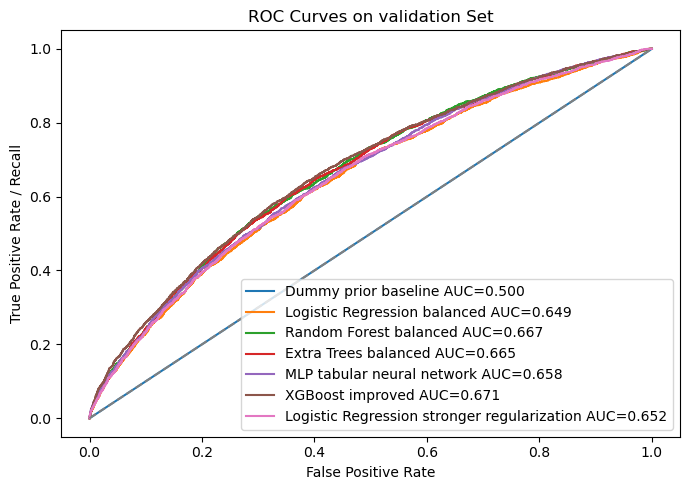

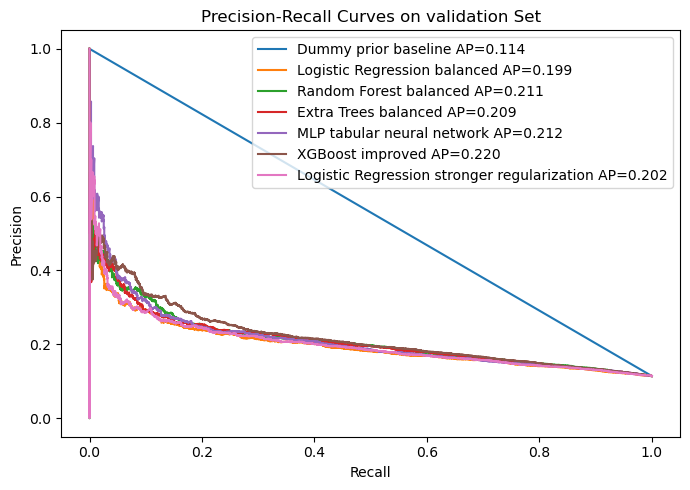

In [45]:
plot_roc_pr_curves(val_results, split_name="validation")

Best validation model by average precision:
XGBoost improved


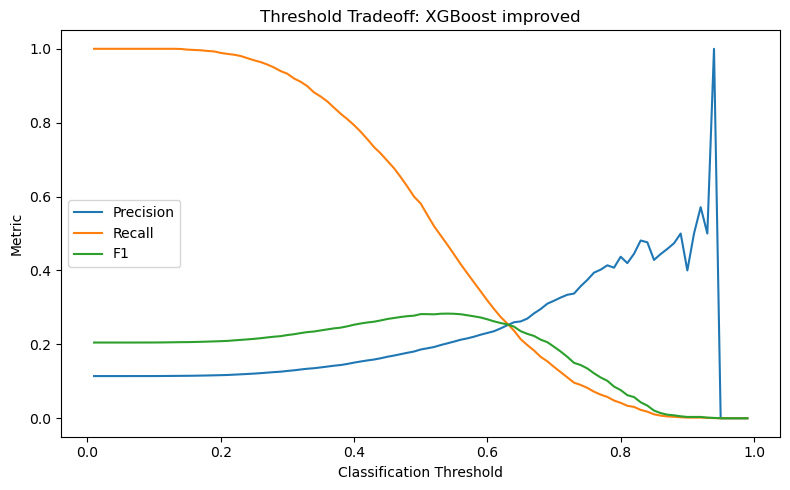

In [46]:
best_val_model_name = val_metrics.index[0]

print("Best validation model by average precision:")
print(best_val_model_name)

threshold_table = threshold_tables[best_val_model_name]

plt.figure(figsize=(8, 5))
plt.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
plt.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric")
plt.title(f"Threshold Tradeoff: {best_val_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
selection_metric = "average_precision"

best_model_name = val_metrics.sort_values(
    selection_metric,
    ascending=False
).index[0]

best_model = trained_models[best_model_name]
best_threshold = val_results[best_model_name]["threshold"]

print("Selected model:", best_model_name)
print("Selected by:", selection_metric)
print("Validation-tuned threshold:", best_threshold)

Selected model: XGBoost improved
Selected by: average_precision
Validation-tuned threshold: 0.49


In [48]:
test_results = OrderedDict()
test_metric_rows = []

for model_name, fitted_model in trained_models.items():
    y_test_score = get_scores(fitted_model, X_test)

    threshold = val_results[model_name]["threshold"]

    metrics = evaluate_predictions(
        y_test,
        y_test_score,
        threshold=threshold
    )

    metrics["model"] = model_name

    test_metric_rows.append(metrics)

    test_results[model_name] = {
        "y_true": y_test,
        "y_score": y_test_score,
        "threshold": threshold
    }

test_metrics = (
    pd.DataFrame(test_metric_rows)
    .set_index("model")
    .sort_values(selection_metric, ascending=False)
)

display(test_metrics.round(4))

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,average_precision
model,,,,,,,,,
XGBoost improved,0.49,0.6456,0.6305,0.1803,0.6110,0.6499,0.2784,0.6700,0.2235
MLP tabular neural network,0.12,0.7128,0.6139,0.1915,0.4865,0.7413,0.2749,0.6587,0.2113
Random Forest balanced,0.42,0.6525,0.6140,0.1745,0.5645,0.6635,0.2666,0.6579,0.2075
Extra Trees balanced,0.45,0.6344,0.6114,0.1696,0.5817,0.6411,0.2626,0.6560,0.2069
Logistic Regression stronger regularization,0.52,0.6774,0.6054,0.1763,0.5126,0.6981,0.2623,0.6494,0.2061
Logistic Regression balanced,0.52,0.6742,0.6030,0.1743,0.5113,0.6948,0.2600,0.6457,0.2040
Dummy prior baseline,0.01,0.1119,0.5000,0.1119,1.0000,0.0000,0.2013,0.5000,0.1119


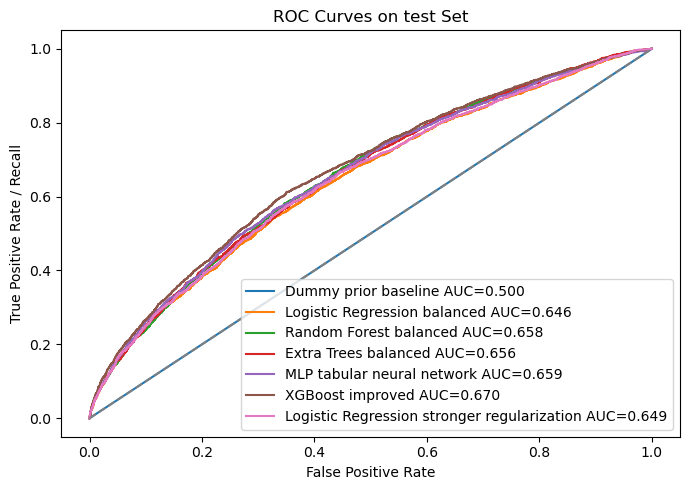

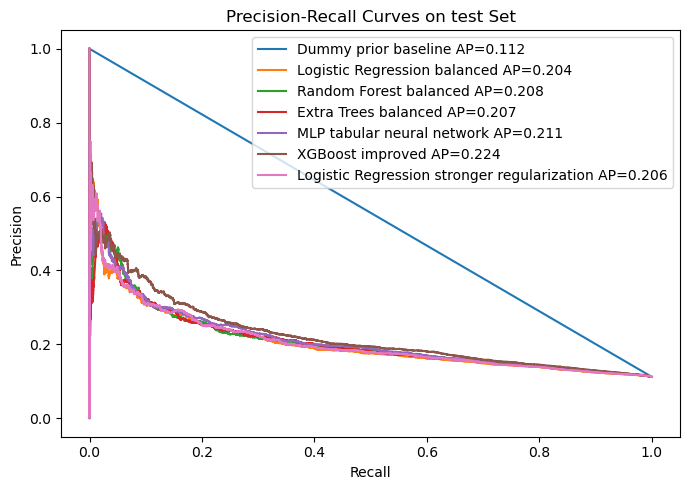

In [49]:
plot_roc_pr_curves(test_results, split_name="test")

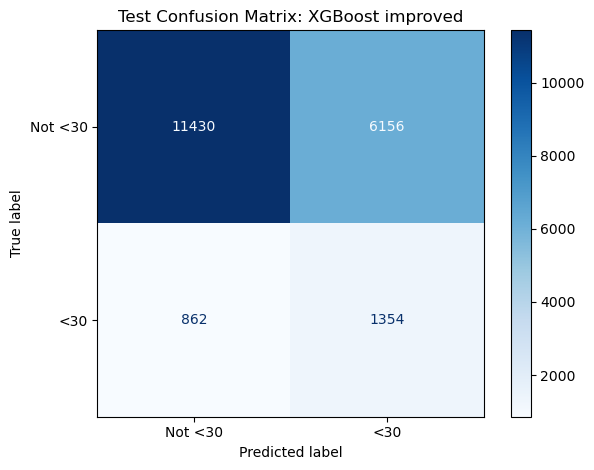

                    precision    recall  f1-score   support

Not readmitted <30     0.9299    0.6499    0.7651     17586
    Readmitted <30     0.1803    0.6110    0.2784      2216

          accuracy                         0.6456     19802
         macro avg     0.5551    0.6305    0.5218     19802
      weighted avg     0.8460    0.6456    0.7106     19802



In [50]:
y_test_score_best = test_results[best_model_name]["y_score"]
y_test_pred_best = (y_test_score_best >= best_threshold).astype(int)

plot_confusion(
    y_test,
    y_test_score_best,
    best_threshold,
    f"Test Confusion Matrix: {best_model_name}"
)

print(
    classification_report(
        y_test,
        y_test_pred_best,
        target_names=["Not readmitted <30", "Readmitted <30"],
        digits=4
    )
)

In [51]:
def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    feature_names = []

    feature_names.extend(numeric_features)

    cat_pipeline = preprocessor.named_transformers_["cat"]
    ohe = cat_pipeline.named_steps["onehot"]

    try:
        categorical_names = ohe.get_feature_names_out(categorical_features).tolist()
    except Exception:
        categorical_names = ohe.get_feature_names(categorical_features).tolist()

    feature_names.extend(categorical_names)

    return np.array(feature_names)

In [52]:
logistic_model_names = [
    name for name in trained_models
    if "Logistic Regression" in name
]

if len(logistic_model_names) > 0:
    logistic_name = logistic_model_names[0]
    logistic_model = trained_models[logistic_name]

    feature_names = get_feature_names_from_preprocessor(
        logistic_model.named_steps["preprocess"],
        numeric_features,
        categorical_features
    )

    coefficients = logistic_model.named_steps["model"].coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

    top_positive = coef_df.sort_values(
        "coefficient",
        ascending=False
    ).head(20)

    top_negative = coef_df.sort_values(
        "coefficient",
        ascending=True
    ).head(20)

    print("Top predictors increasing predicted readmission risk:")
    display(top_positive)

    print("Top predictors decreasing predicted readmission risk:")
    display(top_negative)

else:
    print("No logistic regression model was found.")

Top predictors increasing predicted readmission risk:


,feature,coefficient,abs_coefficient
368,diag_1_V58,1.544670,1.544670
538,diag_2_625,1.542047,1.542047
831,diag_3_V64,1.184128,1.184128
231,diag_1_443,1.135222,1.135222
303,diag_1_642,0.994397,0.994397
597,diag_2_V49,0.954169,0.954169
84,medical_specialty_Hematology,0.951624,0.951624
712,diag_3_444,0.944112,0.944112
440,diag_2_332,0.941275,0.941275
297,diag_1_608,0.938871,0.938871


Top predictors decreasing predicted readmission risk:


,feature,coefficient,abs_coefficient
433,diag_2_301,-1.868891,1.868891
703,diag_3_429,-1.721841,1.721841
740,diag_3_537,-1.578563,1.578563
198,diag_1_386,-1.574633,1.574633
98,medical_specialty_Otolaryngology,-1.515375,1.515375
573,diag_2_807,-1.490279,1.490279
516,diag_2_568,-1.420915,1.420915
553,diag_2_728,-1.372811,1.372811
484,diag_2_455,-1.369205,1.369205
584,diag_2_E849,-1.362746,1.362746


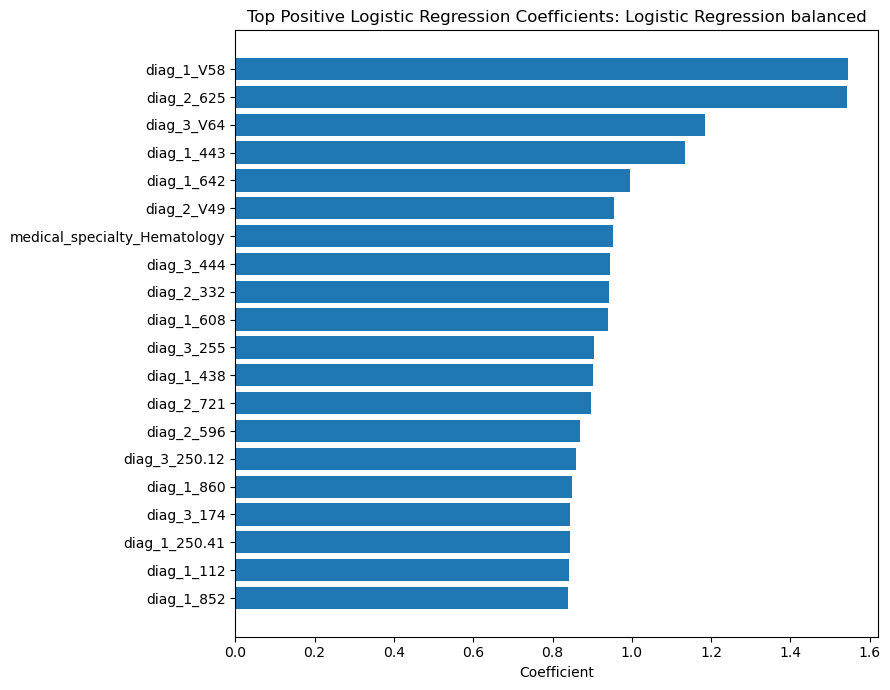

In [53]:
if len(logistic_model_names) > 0:
    plt.figure(figsize=(9, 7))

    plot_df = top_positive.sort_values("coefficient")

    plt.barh(
        plot_df["feature"],
        plot_df["coefficient"]
    )

    plt.title(f"Top Positive Logistic Regression Coefficients: {logistic_name}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

In [54]:
RUN_PERMUTATION_IMPORTANCE = True
PERMUTATION_SAMPLE_SIZE = 3000 if FAST_MODE else 5000

if RUN_PERMUTATION_IMPORTANCE:
    X_perm = X_val.sample(
        min(len(X_val), PERMUTATION_SAMPLE_SIZE),
        random_state=RANDOM_STATE
    )

    y_perm = y_val.loc[X_perm.index]

    print(f"Running permutation importance on {len(X_perm)} validation rows...")

    permutation_result = permutation_importance(
        best_model,
        X_perm,
        y_perm,
        scoring="average_precision",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    perm_df = pd.DataFrame({
        "feature": X_perm.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std
    })

    perm_df = perm_df.sort_values(
        "importance_mean",
        ascending=False
    )

    display(perm_df.head(25))

else:
    print("Permutation importance skipped.")

Running permutation importance on 5000 validation rows...


,feature,importance_mean,importance_std
14,number_inpatient,0.040128,0.003577
4,discharge_disposition_id,0.031498,0.003478
64,prior_visit_burden,0.009271,0.001694
17,diag_3,0.003713,0.001371
13,number_emergency,0.003103,0.000403
15,diag_1,0.003005,0.002321
7,payer_code,0.002755,0.001868
78,visit_intensity,0.002082,0.001460
66,log_inpatient,0.001638,0.000592
76,labs_per_day,0.001557,0.000552


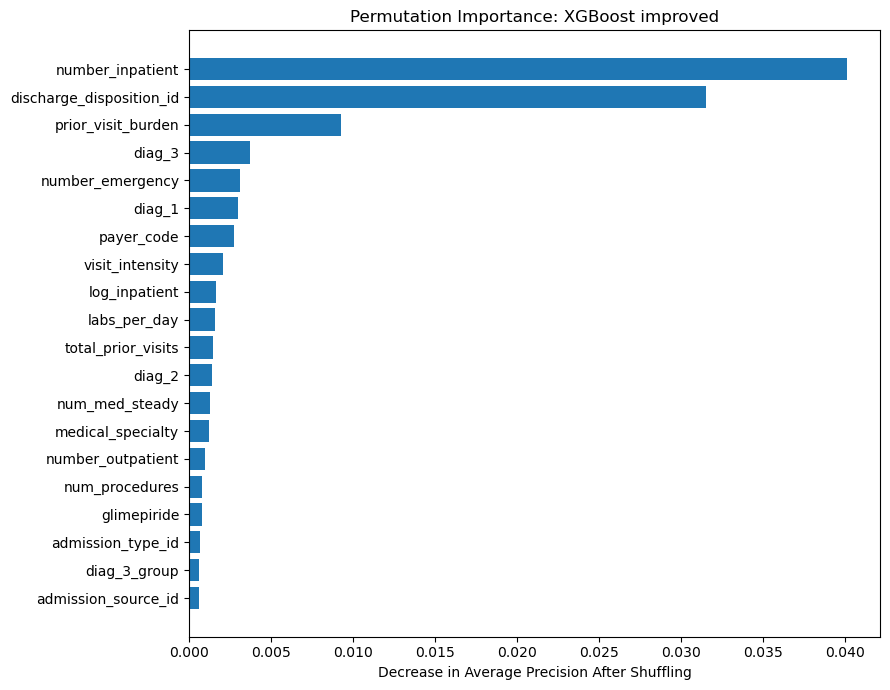

In [55]:
if RUN_PERMUTATION_IMPORTANCE:
    plt.figure(figsize=(9, 7))

    plot_df = perm_df.head(20).sort_values("importance_mean")

    plt.barh(
        plot_df["feature"],
        plot_df["importance_mean"]
    )

    plt.xlabel("Decrease in Average Precision After Shuffling")
    plt.title(f"Permutation Importance: {best_model_name}")
    plt.tight_layout()
    plt.show()

In [56]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [57]:
print("Selected model before calibration:", best_model_name)
print("Original validation threshold:", best_threshold)

# Get uncalibrated validation and test scores
y_val_score_best = get_scores(best_model, X_val)
y_test_score_best = get_scores(best_model, X_test)

uncalibrated_metrics = evaluate_predictions(
    y_test,
    y_test_score_best,
    threshold=best_threshold
)

print("Uncalibrated test metrics:")
display(pd.Series(uncalibrated_metrics).round(4))

Selected model before calibration: XGBoost improved
Original validation threshold: 0.49
Uncalibrated test metrics:


threshold            0.4900
accuracy             0.6456
balanced_accuracy    0.6305
precision            0.1803
recall               0.6110
specificity          0.6499
f1                   0.2784
roc_auc              0.6700
average_precision    0.2235
dtype: float64

In [58]:
# Calibrate the already-trained best model using the validation set.
# This does not retrain the full model; it adjusts probability estimates.

try:
    calibrated_model = CalibratedClassifierCV(
        estimator=best_model,
        method="isotonic",
        cv="prefit"
    )
except TypeError:
    calibrated_model = CalibratedClassifierCV(
        base_estimator=best_model,
        method="isotonic",
        cv="prefit"
    )

calibrated_model.fit(X_val, y_val)

print("Calibration complete.")

Calibration complete.


In [59]:
# Get calibrated scores
y_val_score_calibrated = calibrated_model.predict_proba(X_val)[:, 1]
y_test_score_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# Tune threshold again using calibrated validation scores
calibrated_threshold, calibrated_threshold_table = find_threshold_for_recall_with_precision(
    y_val,
    y_val_score_calibrated,
    min_precision=0.18
)

print("Calibrated threshold:", calibrated_threshold)

Calibrated threshold: 0.12


In [60]:
calibrated_metrics = evaluate_predictions(
    y_test,
    y_test_score_calibrated,
    threshold=calibrated_threshold
)

print("Calibrated test metrics:")
display(pd.Series(calibrated_metrics).round(4))

Calibrated test metrics:


threshold            0.1200
accuracy             0.6622
balanced_accuracy    0.6280
precision            0.1832
recall               0.5839
specificity          0.6720
f1                   0.2789
roc_auc              0.6690
average_precision    0.2145
dtype: float64

In [61]:
comparison_calibration = pd.DataFrame([
    pd.Series(uncalibrated_metrics, name="Uncalibrated"),
    pd.Series(calibrated_metrics, name="Calibrated")
])

display(comparison_calibration.round(4))

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,average_precision
Uncalibrated,0.49,0.6456,0.6305,0.1803,0.6110,0.6499,0.2784,0.670,0.2235
Calibrated,0.12,0.6622,0.6280,0.1832,0.5839,0.6720,0.2789,0.669,0.2145


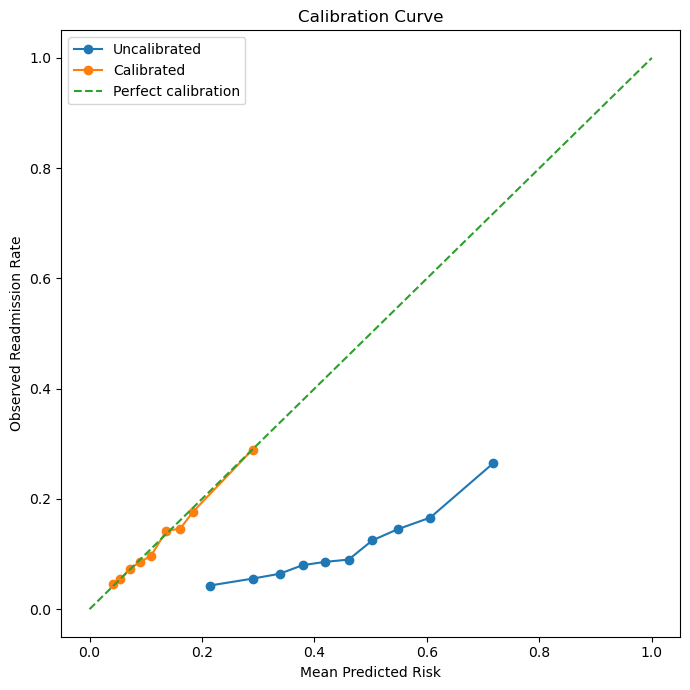

In [62]:
prob_true_uncal, prob_pred_uncal = calibration_curve(
    y_test,
    y_test_score_best,
    n_bins=10,
    strategy="quantile"
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test,
    y_test_score_calibrated,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred_uncal,
    prob_true_uncal,
    marker="o",
    label="Uncalibrated"
)

plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    label="Calibrated"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Risk")
plt.ylabel("Observed Readmission Rate")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
risk_df = pd.DataFrame({
    "y_true": y_test.values,
    "risk_score": y_test_score_calibrated
})

risk_df["risk_group"] = pd.qcut(
    risk_df["risk_score"].rank(method="first"),
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

risk_summary = (
    risk_df
    .groupby("risk_group")
    .agg(
        patients=("y_true", "count"),
        observed_readmission_rate=("y_true", "mean"),
        mean_predicted_risk=("risk_score", "mean")
    )
    .reset_index()
)

display(risk_summary.round(4))

,risk_group,patients,observed_readmission_rate,mean_predicted_risk
0,Very Low,3961,0.0492,0.0471
1,Low,3960,0.0722,0.0710
2,Medium,3960,0.0894,0.0956
3,High,3960,0.1361,0.1381
4,Very High,3961,0.2126,0.2214


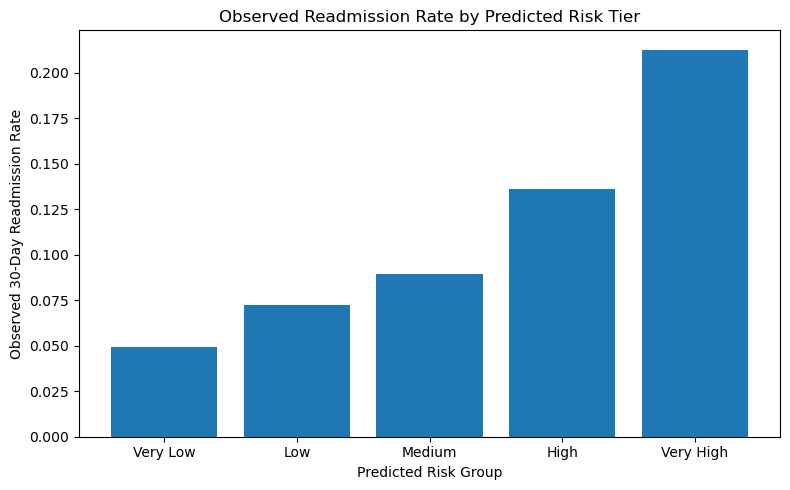

In [66]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["risk_group"].astype(str),
    risk_summary["observed_readmission_rate"]
)

plt.xlabel("Predicted Risk Group")
plt.ylabel("Observed 30-Day Readmission Rate")
plt.title("Observed Readmission Rate by Predicted Risk Tier")
plt.tight_layout()
plt.show()

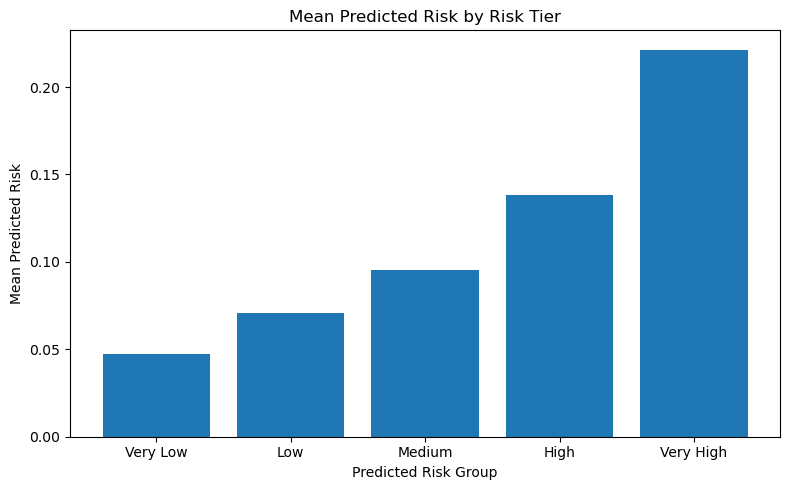

In [67]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["risk_group"].astype(str),
    risk_summary["mean_predicted_risk"]
)

plt.xlabel("Predicted Risk Group")
plt.ylabel("Mean Predicted Risk")
plt.title("Mean Predicted Risk by Risk Tier")
plt.tight_layout()
plt.show()

In [68]:
def subgroup_metrics(raw_split_df, y_true, y_score, threshold, group_col):
    if group_col not in raw_split_df.columns:
        print(f"{group_col} not found in dataframe.")
        return pd.DataFrame()

    y_true_series = pd.Series(
        y_true.values if hasattr(y_true, "values") else y_true,
        index=raw_split_df.index
    ).astype(int)

    y_score_series = pd.Series(
        y_score,
        index=raw_split_df.index
    ).astype(float)

    y_pred_series = (y_score_series >= threshold).astype(int)

    rows = []

    for group_value, group_index in raw_split_df.groupby(group_col).groups.items():
        group_index = list(group_index)

        yt = y_true_series.loc[group_index]
        yp = y_pred_series.loc[group_index]
        ys = y_score_series.loc[group_index]

        if len(yt) < 25:
            continue

        tn, fp, fn, tp = confusion_matrix(
            yt,
            yp,
            labels=[0, 1]
        ).ravel()

        row = {
            "group_column": group_col,
            "group": group_value,
            "n": len(yt),
            "observed_readmission_rate": yt.mean(),
            "predicted_positive_rate": yp.mean(),
            "precision": precision_score(yt, yp, zero_division=0),
            "recall": recall_score(yt, yp, zero_division=0),
            "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "f1": f1_score(yt, yp, zero_division=0)
        }

        try:
            row["roc_auc"] = roc_auc_score(yt, ys)
        except ValueError:
            row["roc_auc"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

In [69]:
fairness_frames = []

for group_col in ["race", "gender", "age"]:
    group_result = subgroup_metrics(
        raw_split_df=test,
        y_true=y_test,
        y_score=y_test_score_calibrated,
        threshold=calibrated_threshold,
        group_col=group_col
    )

    fairness_frames.append(group_result)

fairness_df = pd.concat(
    fairness_frames,
    ignore_index=True
)

display(
    fairness_df
    .sort_values(["group_column", "group"])
    .round(4)
)

,group_column,group,n,observed_readmission_rate,predicted_positive_rate,precision,recall,false_positive_rate,false_negative_rate,f1,roc_auc
7,age,[0-10),29,0.0345,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.6071
8,age,[10-20),138,0.0652,0.0870,0.1667,0.2222,0.0775,0.7778,0.1905,0.5896
9,age,[20-30),388,0.1546,0.3454,0.3731,0.8333,0.2561,0.1667,0.5155,0.8587
10,age,[30-40),729,0.1056,0.2428,0.2486,0.5714,0.2040,0.4286,0.3465,0.7148
11,age,[40-50),1909,0.1058,0.2651,0.1798,0.4505,0.2431,0.5495,0.2571,0.6567
12,age,[50-60),3469,0.1026,0.2514,0.2110,0.5169,0.2210,0.4831,0.2997,0.7074
13,age,[60-70),4266,0.1088,0.3247,0.1827,0.5453,0.2977,0.4547,0.2737,0.6544
14,age,[70-80),5040,0.1165,0.4220,0.1735,0.6286,0.3948,0.3714,0.2719,0.6523
15,age,[80-90),3287,0.1186,0.4779,0.1661,0.6692,0.4522,0.3308,0.2662,0.6368
16,age,[90-100),547,0.1280,0.5082,0.1439,0.5714,0.4990,0.4286,0.2299,0.5448


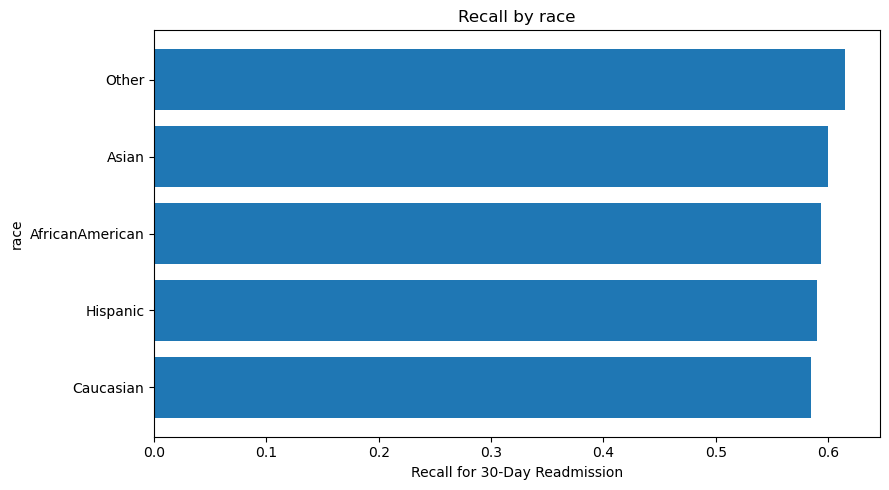

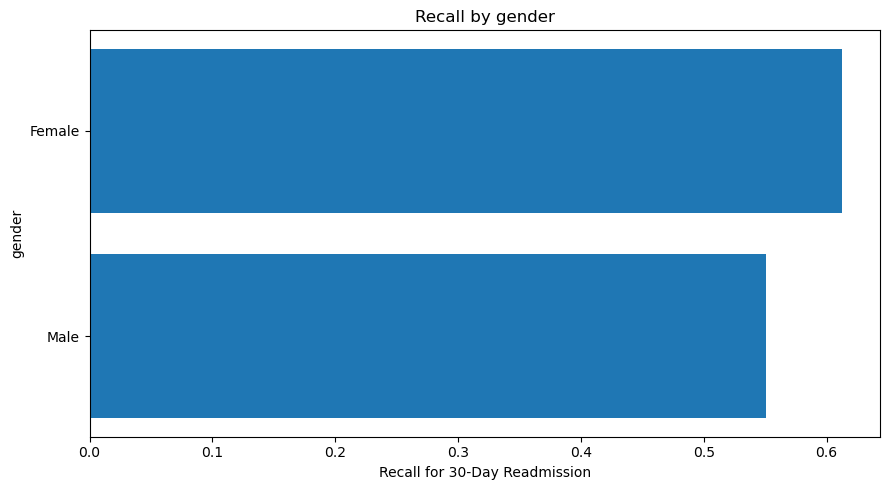

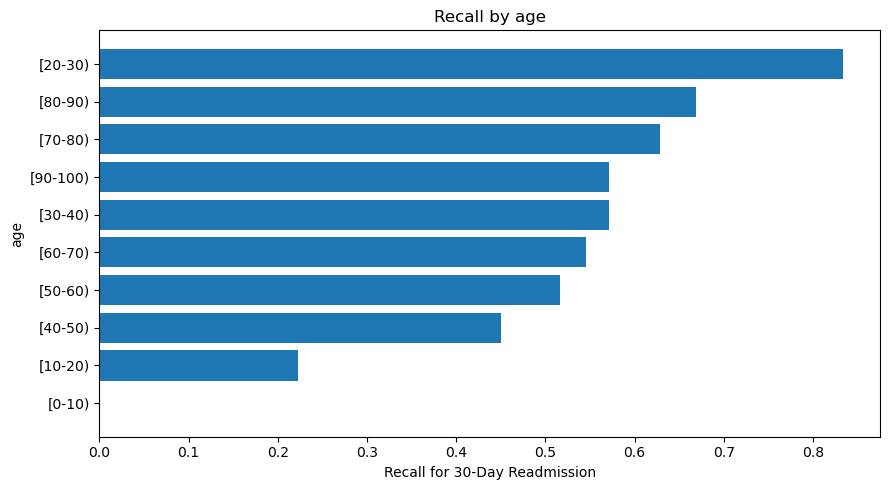

In [70]:
for group_col in ["race", "gender", "age"]:
    plot_df = fairness_df[
        fairness_df["group_column"] == group_col
    ].copy()

    if plot_df.empty:
        continue

    plot_df = plot_df.sort_values("recall")

    plt.figure(figsize=(9, 5))

    plt.barh(
        plot_df["group"].astype(str),
        plot_df["recall"]
    )

    plt.xlabel("Recall for 30-Day Readmission")
    plt.ylabel(group_col)
    plt.title(f"Recall by {group_col}")
    plt.tight_layout()
    plt.show()

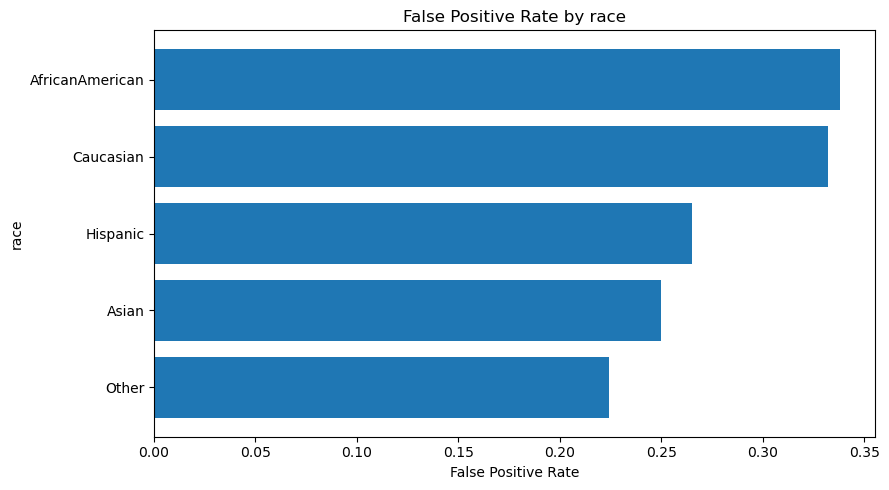

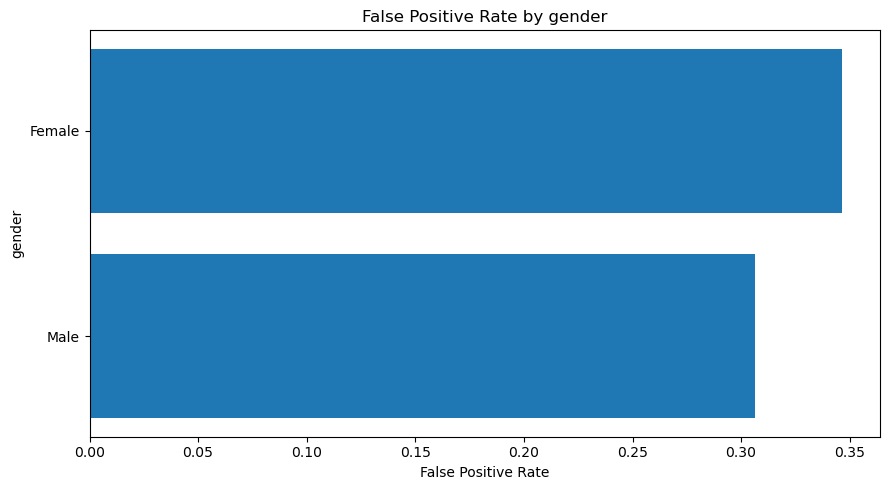

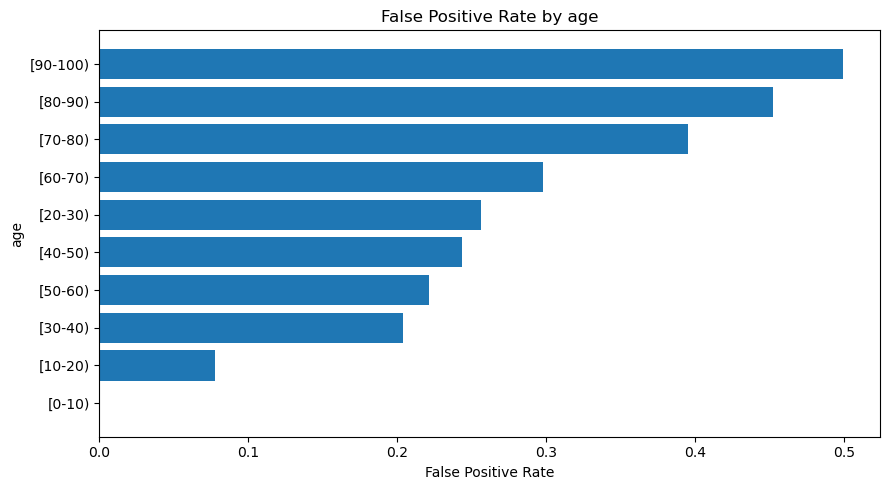

In [71]:
for group_col in ["race", "gender", "age"]:
    plot_df = fairness_df[
        fairness_df["group_column"] == group_col
    ].copy()

    if plot_df.empty:
        continue

    plot_df = plot_df.sort_values("false_positive_rate")

    plt.figure(figsize=(9, 5))

    plt.barh(
        plot_df["group"].astype(str),
        plot_df["false_positive_rate"]
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel(group_col)
    plt.title(f"False Positive Rate by {group_col}")
    plt.tight_layout()
    plt.show()

In [72]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

comparison_calibration.to_csv(
    OUTPUT_DIR / "calibration_comparison.csv"
)

risk_summary.to_csv(
    OUTPUT_DIR / "risk_tier_summary.csv",
    index=False
)

fairness_df.to_csv(
    OUTPUT_DIR / "fairness_subgroup_metrics.csv",
    index=False
)

print("Saved calibration, risk-tier, and fairness outputs.")

Saved calibration, risk-tier, and fairness outputs.
